# Smart Charging using Reinforcement Learning
Task description is summarized as follows:
- EV taxi is charged at home and an RL agent should manage the charging to complete the working day
- EV arrives at <b>2 p.m. at leaves at 4 p.m. each day</b>
- Adjustments to charging power can be made <b>every 15 minutes</b>
- Charging power is between 0 kW and 22 kW
- Energy demand follows a normal distribution (𝜇= 30 kWh, 𝜎= 5 kW)
- Energy demand for after 4 pm is generated when leaving
- Running out of energy is the worst case -> high penalty
- Goal is to minimize recharging cost
- Vehicle's battery has a capacity that cannot be exceeded
- Recharging cost follows an exponential function of the power (i.e., charging cost (t, p) = ∑ 𝛼!𝑒" !∈$ ) 𝛼! is the time coefficient and p is the charging rate 
- Create the environment (<b>simple discrete event simulation</b>) that returns agent's decisions and returns reward
- Define markov decision process, inclduing states, actions, and reward function
- Solve MDP using RL algorithm to find optimal charging policies
- Limited charging options such as zero, low, medium, high


## General structure of the notebook
First the stochastic distributions are modelled (demand and cost). Then the environment is set up with a Markov Decision Process. This process is then used by the learner.
We train a baseline as first "model" based on a simple rule. Then the models Monte Carlo and DQN's hyperparameter are optimized. Then they are trained on the same amount of episodes and respective time steps. Lastly these trained agents are then tested on an additional number of episodes

## Assumptions
As not all information are defined by the task, we work with assumptions.

> Assumption: We use a 60 kWh battery capacity which is in the middle of some german car manufacturer ([OPEL](https://www.opel.de/e-mobilitaet/elektro-modelle.html), [BMW](https://www.bmw.de/de/elektroauto.html#modelle))

> Assumption: There is no description about how much energy is left in the battery when the car arrives. Therefore we randomly select one based on the normal distribution, assuming that the taxi does a trip before 2 pm of the same scale.

> Assumption: The driver will not return with a completely empty battery, hence the minimum sampled will be 0.5 kWh.

> Assumption: As the vehicle is charged at home, we assume that the energy therefore alpha is set to 1

> Assumption: To avoid that the prices skyrock (e^22), we normalize it through the maximal power

> Assumption: Available battery capacity and charging speed decide about how much is actually charged. This estimated value is used for cost calculation.

In [ ]:
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import TransformReward
import torch
from joblib import Parallel, delayed
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement
from stable_baselines3.common.monitor import Monitor

RANDOM_SEED = 42
BATTERY_CAPACITY = 60.0               # kWh - battery size

This notebook has a sample mode which can be activated in belows cell. The models are then trained on less episodes. <b>Numbers in below markdown cells reference the full mode and not the sample mode.</b>

In [66]:
# ==========================================================================
# SAMPLE MODE
# Set to True for a test run that shows that the notebook runs through. 
# The number of episodes/timestamps is reduced to a small number to make the notbook faster.
#
# DQN counts environment steps, Monte Carlo counts episodes, and every episode
# is exactly 8 steps. So the DQN timestep budgets are set to the matching Monte
# Carlo episode budget * 8, which makes both agents consume the same amount of
# environment interaction in the search and in the final run.
# ==========================================================================
N_STEPS = 8 

SAMPLE_MODE = False



if SAMPLE_MODE:
    EVAL_EPISODES            = 1_000     # rollout episodes for every evaluation
    SEARCH_TRAIN_EPISODES    = 10_000    # Monte Carlo per-combination search budget
    SEARCH_EVAL_EPISODES     = 1_000
    MC_FINAL_EPISODES        = 25_000    # Monte Carlo final training budget
    DQN_SEARCH_EVAL_EPISODES = 500
    # the final run keeps the MC * 8 tie, so the learning curves stay comparable.
    # The search budget stays below that tie on purpose: it is paid 486 times,
    # and matching it would turn the quick check into a long run
    DQN_SEARCH_TIMESTEPS     = 10_000
    DQN_FINAL_TIMESTEPS      = MC_FINAL_EPISODES * N_STEPS       # 200_000, matches MC final
    print("SAMPLE_MODE is ON.")
else:
    EVAL_EPISODES            = 5_000
    SEARCH_TRAIN_EPISODES    = 50_000
    SEARCH_EVAL_EPISODES     = 5_000
    MC_FINAL_EPISODES        = 250_000
    DQN_SEARCH_EVAL_EPISODES = 1_000
    DQN_SEARCH_TIMESTEPS     = SEARCH_TRAIN_EPISODES * N_STEPS   # 400_000, matches MC search
    DQN_FINAL_TIMESTEPS      = MC_FINAL_EPISODES * N_STEPS       # 2_000_000, matches MC final

# 1. Simulation of the environment
Parameters and relevant design elements:
- Entity: Taxi with battery at the home charger
- Events:
    - Start event: Arrival at 2 pm
    - In-between events: Eight decision epochs - from start to end every 15min
    - End event:Departure at 4pm (stochastic demand is realised)
- Activity: Charging for 15 minute time slots at the given power
- Resource: Home charger and battery that cannot be exceeded


## 1.1 Stochastic distributions
### 1.1.1 Energy Demand
<i>"Energy demand follows a normal distribution (𝜇= 30 kWh, 𝜎= 5 kW)"</i>

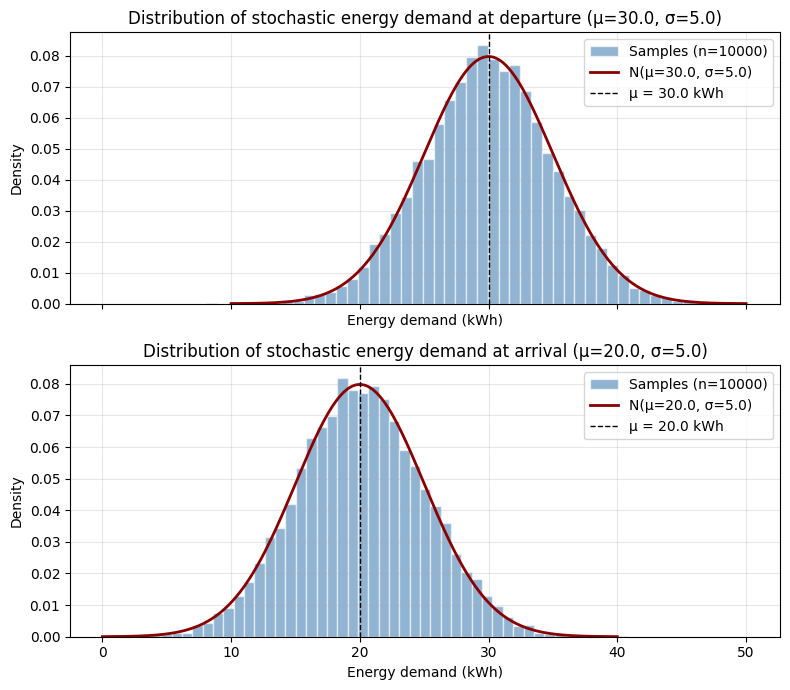

In [67]:
#| label: fig-energy-demand-distribution
#| fig-cap: 'Distribution of the stochastic energy demand sampled at departure ($\mu$=30, $\sigma$=5) and arrival ($\mu$=20, $\sigma$=5). Histograms of 10,000 samples are overlaid with the underlying normal density; the demand is clipped to [0.5, battery capacity].'
demand_rng = np.random.default_rng(RANDOM_SEED)

def sample_energy_demand(mu=30.0, sigma=5.0, generator=demand_rng):
    """
    Draw energy demand from a normal distribution, clipped to
    [0.5, BATTERY_CAPACITY] — can't be negative, and can't exceed
    the battery's maximum capacity.
    """
    demand = generator.normal(mu, sigma)
    return np.clip(demand, 0.5, BATTERY_CAPACITY)


def plot_demand_distribution(ax, mu, sigma, occasion, n_samples=10_000):
    """Draw sampled demands against the underlying normal density on one axis."""
    samples = np.array([sample_energy_demand(mu, sigma) for _ in range(n_samples)])

    ax.hist(samples, bins=50, density=True, alpha=0.6, color="steelblue",
            edgecolor="white", label=f"Samples (n={n_samples})")

    x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 500)
    pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    ax.plot(x, pdf, color="darkred", lw=2, label=f"N(μ={mu}, σ={sigma})")

    ax.axvline(mu, color="black", linestyle="--", lw=1, label=f"μ = {mu} kWh")
    ax.set_xlabel("Energy demand (kWh)")
    ax.set_ylabel("Density")
    ax.set_title(f"Distribution of stochastic energy demand at {occasion} "
                 f"(μ={mu}, σ={sigma})")
    ax.legend()
    ax.grid(alpha=0.3)


_, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
plot_demand_distribution(ax[0], mu=30.0, sigma=5.0, occasion="departure")
plot_demand_distribution(ax[1], mu=20.0, sigma=5.0, occasion="arrival")
plt.tight_layout()
plt.show()

### 1.1.2 Recharging costs
"Recharging cost follows an exponential function of the power (i.e., charging cost (t, p) = ∑ 𝛼!𝑒" !∈$ ) 𝛼! is the time coefficient and p is the charging rate"

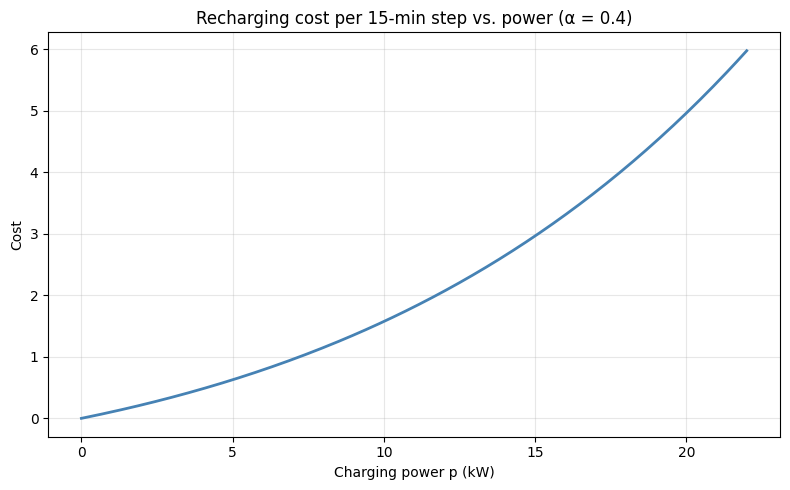

In [68]:
#| label: fig-recharging-cost
#| fig-cap: 'Recharging cost per 15-minute step as a function of charging power ($\alpha$ = 0.4). The cost grows exponentially with the charging power.'
ALPHA = 0.4    # time coefficient alpha_t, constant over time
P_MAX = 22.0   # kW, highest charging rate
DT = 0.25      # hours per 15-min decision step


def charged_energy(power, soc):
    """
    Calculates the energy that can be charged in a single step,
    given the charging power and the available space in the battery.
    """
    space = np.maximum(0.0, BATTERY_CAPACITY - soc)
    return np.minimum(power * DT, space)


def charging_cost(power, energy):
    """
    Calculates the cost of charging a given amount of energy at a given power level,
    using a cost function that increases exponentially with power.
    """
    return ALPHA * energy * np.exp(power / P_MAX)


powers = np.linspace(0, P_MAX, 200)
costs = charging_cost(powers, charged_energy(powers, soc=0.0))

_, ax = plt.subplots(figsize=(8, 5))
ax.plot(powers, costs, color="steelblue", lw=2)
ax.set_xlabel("Charging power p (kW)")
ax.set_ylabel("Cost")
ax.set_title(f"Recharging cost per 15-min step vs. power (α = {ALPHA})")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [69]:
ACTION_POWERS = [0.0, 4.4, 8.8, 13.2, 17.6, 22.0]   # kW, zero to very high
N_ACTIONS = len(ACTION_POWERS)

PENALTY_PER_KWH = 700.0               # penalty for every KWh of unmet demand

# 2. Markov Decision Process

The environment is implemented as a `gymnasium.Env` so that it can be handed directly to a Stable-Baselines3 agent.

**State** $s_t = (t,\ soc_t)$, normalised to $[0,1]$ as $(t/8,\ soc/60)$.

The realised demand is *not* part of the state but is calculated at departure. So the agent is limited to knowing that the time step and the demand.

**Action** $a_t \in \{0,\dots,5\}$. The agent has the possible actions of charging at different speeds: 0 / 4.4 / 8.8 / 13.2 / 17.6 / 22.0 kW 

**Transition** $soc_{t+1} = soc_t + \min(p_{a}\cdot \Delta t,\ 60 - soc_t)$, with $\Delta t = 0.25$ h. Battery capacity is enforced inside `charged_energy()`, so the state can not be overcharged.

**Reward**
Reward consists of negative costs and the penalty which is set for `700 * kWh_missed`

$$r_t = -\alpha \cdot e_t \cdot e^{p_t/p_{max}} \qquad\text{for } t < 8$$

$$r_8 = -\alpha \cdot e_8 \cdot e^{p_8/p_{max}} - 700 \cdot \max(0,\ D - soc_8), \qquad D \sim \mathcal{N}(30, 5)$$

**Horizon** 8 steps, finite and fixed, so every episode terminates at 4 pm (`terminated=True`); `truncated` is always `False` since there is no external time limit.

In [70]:
class ChargingEnv(gym.Env):
    """
    Gymnasium environment for the smart-charging MDP.

    The agent picks a charging power every 15 minutes; the environment returns
    the resulting state, reward and termination flag.

    Each step follows three stages:
      1. the agent selects a charging power,
      2. `charged_energy()` estimates how much the battery absorbs in the
         coming 15 minutes (this is where the step length DT enters),
      3. `charging_cost()` prices that energy at the flat tariff ALPHA.

    """

    def __init__(self):
        super().__init__()
        self.action_space = spaces.Discrete(N_ACTIONS)
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(2,), dtype=np.float32)
        self.rng = np.random.default_rng(RANDOM_SEED)   # must be set once to ensure proper reproducibility
        self.time = 0
        self.state_of_charge = 0.0                      # arrival SoC is drawn in reset()

    def _obs(self):
        """Scale (t, soc) to [0, 1] for the neural network."""
        return np.array(
            [self.time / N_STEPS, self.state_of_charge / BATTERY_CAPACITY],
            dtype=np.float32,
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.time = 0

        self.state_of_charge = float(sample_energy_demand(mu=20, sigma=5, generator=self.rng)) # Select base energy from normal distribution
        return self._obs(), {}

    def step(self, action):
        # Select charging power
        power = ACTION_POWERS[int(action)]

        # Calculate possible energy charged in this step and price
        energy = float(charged_energy(power, self.state_of_charge))
        cost = float(charging_cost(power, energy))

        self.state_of_charge += energy  # no battery overflow, see charged_energy()
        self.time += 1

        reward = -cost
        terminated = self.time >= N_STEPS   # episode ends after 8 steps at departure (4 pm)
        truncated = False                   # no external time limit
        info = {"power": power, "cost": cost, "demand": None, "shortfall": None, "penalty": 0.0}

        # Terminate = departure: realise stochastic demand and penalise unmet energy
        if terminated:
            demand = float(sample_energy_demand(mu=30, sigma=5, generator=self.rng))
            shortfall = max(0.0, demand - self.state_of_charge)
            penalty = PENALTY_PER_KWH * shortfall
            reward -= penalty
            info.update(demand=demand, shortfall=shortfall, penalty=penalty)

        return self._obs(), reward, terminated, truncated, info

# 3. Baseline: evenly distributed charging

To have a baseline, we set the simple rule to charge as much as possible evenly distributed over the 8 time slots.
So on arrival we calculate the energy missing to a full battery and divide it by 8. That gives the kWh per slot; dividing by the slot length $\Delta t = 0.25$ h turns it into the charging power the rule holds for the whole session:

$$p = \frac{60 - soc_0}{8 \cdot \Delta t}$$

If that value is above 22 kW, the rule simply charges as much as possible.

Since the available powers are discrete, the required power is rounded up to the next level, so the baseline slightly overshoots the target rather than undershooting it.

The rule uses only the arrival SoC and never re-plans. It should almost never run out of energy, but it pays for a full battery every day.

In [71]:
def even_spread_action(soc_arrival):
    """
    Baseline rule, decided once on arrival at 2 pm.

    The energy missing to a full battery is spread evenly over the 8 slots.
    Dividing by N_STEPS gives the kWh per slot, dividing by DT turns that into
    the kW the charger has to hold. If more than the strongest level would be
    needed, charge as much as possible instead.
    """
    missing_energy = max(0.0, BATTERY_CAPACITY - soc_arrival)   # kWh
    energy_per_step = missing_energy / N_STEPS                  # kWh per 15-min slot
    required_power = energy_per_step / DT                       # kW held constant for 2 h

    for idx, power in enumerate(ACTION_POWERS):
        if power >= required_power - 1e-9:
            return idx
    return N_ACTIONS - 1                                        # > 22 kW needed -> charge flat out


def run_policy(select_action, n_episodes, seed=RANDOM_SEED):
    """
    Roll out one policy on ChargingEnv and collect per-episode results.

    `select_action(observation, env, soc_arrival)` returns the action index for the
    current step. Baseline, Monte Carlo and DQN all go through this function, so
    they are evaluated on exactly the same episodes and reported in the same format.
    """
    env = ChargingEnv()
    records = []

    for episode in range(n_episodes):
        observation, _ = env.reset(seed=seed + episode) # + changes the policy
        soc_arrival = env.state_of_charge

        total_cost = 0.0
        step_powers = []
        while True:
            action = select_action(observation, env, soc_arrival)
            observation, _, terminated, _, info = env.step(action)
            total_cost += info["cost"]
            step_powers.append(info["power"])
            if terminated:
                break

        records.append({
            "arrival_soc": soc_arrival,
            "power": float(np.mean(step_powers)),
            "final_soc": env.state_of_charge,
            "demand": info["demand"],
            "cost": total_cost,
            "shortfall": info["shortfall"],
            "penalty": info["penalty"],
            "reward": -(total_cost + info["penalty"]),
        })

    return pd.DataFrame(records)


def summarize_results(name, results):
    """Print the per-episode summary used for every policy."""
    print(f"{name}, {len(results)} episodes\n")
    print(f"mean charging cost   {results['cost'].mean():8.2f}")
    print(f"mean penalty         {results['penalty'].mean():8.2f}")
    print(f"mean total reward    {results['reward'].mean():8.2f}")
    print(f"episodes w/ shortfall{results['shortfall'].gt(0).mean():8.2%}")
    print(f"mean shortfall       {results['shortfall'].mean():8.3f} kWh")
    print(f"mean arrival SoC     {results['arrival_soc'].mean():8.2f} kWh")
    print(f"mean final SoC       {results['final_soc'].mean():8.2f} kWh")


def run_baseline(n_episodes, seed=RANDOM_SEED):
    """Roll out the baseline policy: one action decided at 2 pm, then held."""
    return run_policy(
        lambda observation, env, soc_arrival: even_spread_action(soc_arrival),
        n_episodes=n_episodes, seed=seed,
    )


baseline = run_baseline(n_episodes=EVAL_EPISODES)
summarize_results("Baseline: evenly spread charging to a full battery", baseline)

Baseline: evenly spread charging to a full battery, 5000 episodes

mean charging cost      41.77
mean penalty             0.00
mean total reward      -41.77
episodes w/ shortfall   0.00%
mean shortfall          0.000 kWh
mean arrival SoC        20.01 kWh
mean final SoC          59.42 kWh


In [72]:
baseline.describe()

,arrival_soc,power,final_soc,demand,cost,shortfall,penalty,reward
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0,5000.0,5000.000000
mean,20.013908,21.254640,59.418912,29.897190,41.773324,0.0,0.0,-41.773324
std,4.966927,1.712804,1.547606,5.036867,6.477373,0.0,0.0,6.477373
min,0.500000,8.800000,44.500000,11.844948,10.279489,0.0,0.0,-47.841760
25%,16.655863,22.000000,60.000000,26.453304,39.866640,0.0,0.0,-47.128631
50%,19.984372,22.000000,60.000000,29.866849,43.509502,0.0,0.0,-43.509502
75%,23.334707,22.000000,60.000000,33.239110,47.128631,0.0,0.0,-39.866640
max,42.773631,22.000000,60.000000,47.624110,47.841760,0.0,0.0,-10.279489


# 4. Monte Carlo
Reasons why Monte Carlo can be applied:
- Complete eposiodes from arrival to leaving, 8 time-steps
- Return of an episode is the sum of all reparts (charging costs + penalty) which is propagated back to earlier decisions through the mean calculation at every state
- State consists of t and SoC is discrete: 
    - SoC bin size is derived from the action grid as the weakest non-zero charging level $(DT*p=kWh)$
    - Time bins are the 8 time-steps
- Actions are choosen epsilon-greedy during training
- Instead of a constant learning rate, we have a decaying step size ($1/N(s,a)$), so the 
 

In [ ]:
SMALLEST_POWER = min(p for p in ACTION_POWERS if p > 0)   # 4.4 kW, weakest non-zero charging level
SOC_BIN_SIZE = SMALLEST_POWER * DT                        # 1.1 kWh added by that level in one 15-min step
N_SOC_BINS = int(BATTERY_CAPACITY / SOC_BIN_SIZE) + 1     # 55 bins covering 0..60 kWh


def discretize(time, soc):
    """Map the continuous state (t, soc) onto the tabular state (t, soc_bin)."""
    return time, min(int(soc / SOC_BIN_SIZE), N_SOC_BINS - 1)


def train_monte_carlo(n_episodes, epsilon, discount_factor,
                      seed=RANDOM_SEED, record_returns=False,
                      es_check_interval=10_000, es_patience=3,
                      es_min_episodes=50_000, es_min_visits=30, es_tol_frac=0.01):
    # Environment
    env = ChargingEnv()
    env.reset(seed=seed)
    random_generator = np.random.default_rng(seed)

    action_values = np.zeros((N_STEPS, N_SOC_BINS, N_ACTIONS))   # expected return per state-action pair
    visit_counts = np.zeros((N_STEPS, N_SOC_BINS, N_ACTIONS))    # how often each pair was seen
    episode_returns = []                                         # undiscounted return per training episode

    previous_greedy = None                    # greedy policy at the previous convergence check
    stable_checks = 0                         # consecutive checks with a (near-)unchanged policy

    # Run episodes
    for episode_index in range(n_episodes):
        env.reset()
        episode_trajectory = []
        terminated = False
        while not terminated:
            state = discretize(env.time, env.state_of_charge)
            if random_generator.random() < epsilon:
                action = int(random_generator.integers(N_ACTIONS))   # explore
            else:
                action = int(np.argmax(action_values[state]))        # exploit
            _, reward, terminated, _, _ = env.step(action)
            episode_trajectory.append((state, action, reward))

        if record_returns:
            episode_returns.append(sum(reward for _, _, reward in episode_trajectory))

        # walk backwards through the episode and update with the realised return
        episode_return = 0.0
        for state, action, reward in reversed(episode_trajectory):
            episode_return = reward + discount_factor * episode_return
            visit_counts[state][action] += 1
            action_values[state][action] += (
                (episode_return - action_values[state][action]) / visit_counts[state][action]
            )

        # early stopping: has the greedy policy over well-visited states stopped changing?
        if (episode_index + 1) % es_check_interval == 0:
            greedy = np.argmax(action_values, axis=2)
            visited = visit_counts.sum(axis=2) >= es_min_visits      # states seen enough to trust
            if previous_greedy is not None:
                changed = int(np.count_nonzero((greedy != previous_greedy) & visited))
                denom = max(1, int(visited.sum()))
                if (episode_index + 1) >= es_min_episodes and changed / denom <= es_tol_frac:
                    stable_checks += 1
                else:
                    stable_checks = 0
                if stable_checks >= es_patience:
                    break
            previous_greedy = greedy

    if record_returns:
        return action_values, np.array(episode_returns)
    return action_values


def run_monte_carlo(action_values, n_episodes, seed=RANDOM_SEED):
    """Roll out the greedy policy learned by Monte Carlo control, re-decided every 15 min."""
    def greedy_action(observation, env, soc_arrival):
        return int(np.argmax(action_values[discretize(env.time, env.state_of_charge)]))

    return run_policy(greedy_action, n_episodes=n_episodes, seed=seed)


print(f"SoC bin size: {SOC_BIN_SIZE:.2f} kWh -> {N_SOC_BINS} bins")

SoC bin size: 1.10 kWh -> 55 bins


## 4.1 Hyperparameter optimization

Grid search over the exploration rate and the discount factor:
- Epsilon: 0.0, 0.05, 0.1, 0.2, 0.3
- Gamma: 1.0, 0.95, 0.9, 0.8, 0.7
- Every combination is trained from scratch and its greedy policy is evaluated on the same episodes
- Training uses fewer episodes than the final run to keep the 25 combinations tractable
- Each run stops early once the greedy policy from the value table stays (near-)unchanged over several consecutive checks
- The best combination is used for the final training in 4.2

In [74]:
EPSILON_GRID = [0.0, 0.05, 0.1, 0.2, 0.3]
GAMMA_GRID = [1.0, 0.95, 0.9, 0.8, 0.7]

# SEARCH_TRAIN_EPISODES / SEARCH_EVAL_EPISODES come from the SAMPLE MODE config cell

search_records = []

for epsilon in EPSILON_GRID:
    for gamma in GAMMA_GRID:
        candidate_values = train_monte_carlo(
            n_episodes=SEARCH_TRAIN_EPISODES,
            epsilon=epsilon,
            discount_factor=gamma,
        )
        results = run_monte_carlo(candidate_values, n_episodes=SEARCH_EVAL_EPISODES)

        search_records.append({
            "epsilon": epsilon,
            "gamma": gamma,
            "cost": results["cost"].mean(),
            "penalty": results["penalty"].mean(),
            "reward": results["reward"].mean(),
            "shortfall_share": results["shortfall"].gt(0).mean(),
            "final_soc": results["final_soc"].mean(),
        })
        print(f"epsilon {epsilon:.2f} | gamma {gamma:.2f} -> reward {search_records[-1]['reward']:8.2f}")

hyperparameter_search = pd.DataFrame(search_records).sort_values("reward", ascending=False)

best_epsilon = float(hyperparameter_search.iloc[0]["epsilon"])
best_gamma = float(hyperparameter_search.iloc[0]["gamma"])
best_reward = float(hyperparameter_search.iloc[0]["reward"])

print(f"\nBest combination: epsilon {best_epsilon:.2f}, gamma {best_gamma:.2f} "
      f"with mean reward {best_reward:.2f}")
print(f"Spread over all {len(hyperparameter_search)} combinations: "
      f"{hyperparameter_search['reward'].min():.2f} to {hyperparameter_search['reward'].max():.2f}")

epsilon 0.00 | gamma 1.00 -> reward   -21.59
epsilon 0.00 | gamma 0.95 -> reward   -21.32
epsilon 0.00 | gamma 0.90 -> reward   -21.35
epsilon 0.00 | gamma 0.80 -> reward   -21.19
epsilon 0.00 | gamma 0.70 -> reward   -20.70
epsilon 0.05 | gamma 1.00 -> reward   -22.85
epsilon 0.05 | gamma 0.95 -> reward   -22.59
epsilon 0.05 | gamma 0.90 -> reward   -22.92
epsilon 0.05 | gamma 0.80 -> reward   -21.01
epsilon 0.05 | gamma 0.70 -> reward   -21.87
epsilon 0.10 | gamma 1.00 -> reward   -22.59
epsilon 0.10 | gamma 0.95 -> reward   -21.73
epsilon 0.10 | gamma 0.90 -> reward   -22.25
epsilon 0.10 | gamma 0.80 -> reward   -21.31
epsilon 0.10 | gamma 0.70 -> reward   -21.80
epsilon 0.20 | gamma 1.00 -> reward   -23.45
epsilon 0.20 | gamma 0.95 -> reward   -22.17
epsilon 0.20 | gamma 0.90 -> reward   -21.58
epsilon 0.20 | gamma 0.80 -> reward   -22.31
epsilon 0.20 | gamma 0.70 -> reward   -22.99
epsilon 0.30 | gamma 1.00 -> reward   -23.57
epsilon 0.30 | gamma 0.95 -> reward   -21.57
epsilon 0.

In [75]:
hyperparameter_search.pivot(index="epsilon", columns="gamma", values="reward").round(2)

gamma,0.70,0.80,0.90,0.95,1.00
epsilon,,,,,
0.00,-20.70,-21.19,-21.35,-21.32,-21.59
0.05,-21.87,-21.01,-22.92,-22.59,-22.85
0.10,-21.80,-21.31,-22.25,-21.73,-22.59
0.20,-22.99,-22.31,-21.58,-22.17,-23.45
0.30,-21.44,-22.08,-22.45,-21.57,-23.57


## 4.2 Final training and evaluation

- The agent is trained one last time with the best combination from the grid search, using the full number of episodes
- Training stops early once the greedy policy from the value table stays (near-)unchanged over several consecutive checks
- The resulting greedy policy is evaluated on the same episodes as the baseline

In [76]:
mc_action_values, mc_episode_returns = train_monte_carlo(
    n_episodes=MC_FINAL_EPISODES,
    epsilon=best_epsilon,
    discount_factor=best_gamma,
    record_returns=True,   # keep the per-episode training returns for the learning curve
)

print(f"Final training with epsilon {best_epsilon:.2f} and gamma {best_gamma:.2f}")
print(f"Trained action-value table: {mc_action_values.shape} (time steps x SoC bins x actions)\n")

monte_carlo = run_monte_carlo(mc_action_values, n_episodes=EVAL_EPISODES)
summarize_results("Monte Carlo: greedy policy from tabular MC control", monte_carlo)

Final training with epsilon 0.00 and gamma 0.70
Trained action-value table: (8, 55, 6) (time steps x SoC bins x actions)

Monte Carlo: greedy policy from tabular MC control, 5000 episodes

mean charging cost      19.81
mean penalty             0.79
mean total reward      -20.60
episodes w/ shortfall   0.14%
mean shortfall          0.001 kWh
mean arrival SoC        20.01 kWh
mean final SoC          45.23 kWh


In [77]:
monte_carlo.describe()

,arrival_soc,power,final_soc,demand,cost,shortfall,penalty,reward
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.013908,12.610400,45.234708,29.897190,19.813318,0.001129,0.790512,-20.603830
std,4.966927,2.212152,0.892757,5.036867,4.861377,0.035603,24.922059,25.400670
min,0.500000,2.750000,39.000000,11.844948,4.237863,0.000000,0.000000,-1351.731468
25%,16.655863,11.550000,44.526889,26.453304,17.539496,0.000000,0.000000,-21.592058
50%,19.984372,12.650000,45.018654,29.866849,18.987912,0.000000,0.000000,-18.987912
75%,23.334707,13.750000,45.882262,33.239110,21.592058,0.000000,0.000000,-17.539496
max,42.773631,19.800000,49.064745,47.624110,39.588688,1.905989,1334.191971,-4.237863


## 4.3 The learned value function and policy

We visualise the state value $V(s)=\max_a Q(s,a)$ next to the greedy action for each state, over the (decision time × battery energy) grid. Cells the $\epsilon$-greedy agent never visited are grey. The dashed line marks the mean departure demand (30 kWh) the battery should cover by 4 pm.

Because the charging cost grows exponentially with power, the value collapses for states that are still well below the demand late in the session because from there the only way to avoid the 700-per-kWh shortfall is expensive high-power charging. States already above the demand carry almost no remaining cost, so their value sits close to zero.

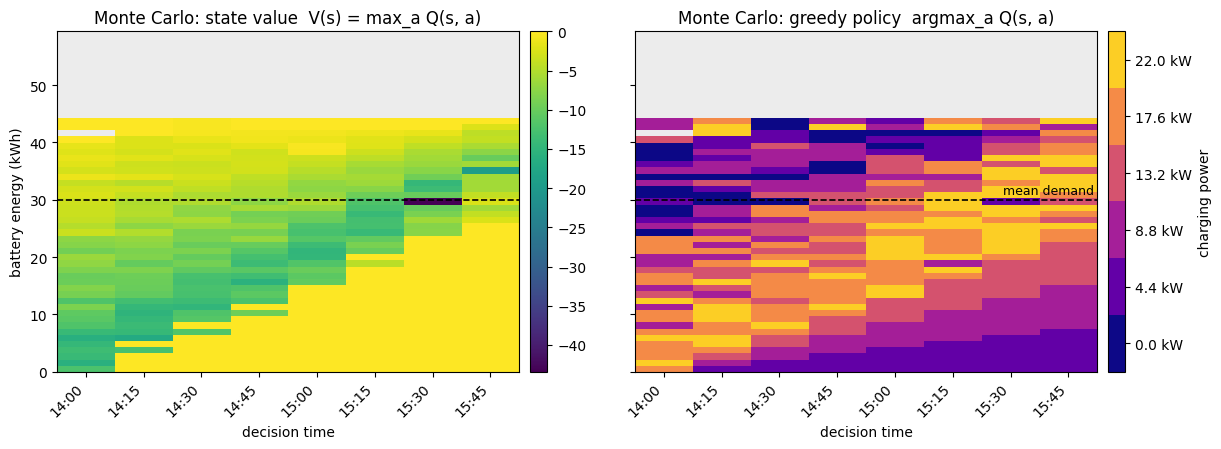

In [ ]:
#| label: fig-mc-value-policy
#| fig-cap: 'Monte Carlo agent: state value $V(s) = \max_a Q(s, a)$ (left) and greedy policy $\arg\max_a Q(s, a)$ (right) over battery energy and the eight 15-minute decision times. Grey cells were never visited during training; the dashed line marks the mean departure demand.'
# discrete colour per charging level, ordered from off (0 kW) to full power
ACTION_LABELS = [f"{p:.1f} kW" for p in ACTION_POWERS]
ACTION_COLORS = ListedColormap(plt.cm.plasma(np.linspace(0.0, 0.9, N_ACTIONS)))
MEAN_DEPARTURE_DEMAND = 30.0                                    # mu of the departure demand (kWh)
CLOCK = [f"{14 + (t * 15) // 60:02d}:{(t * 15) % 60:02d}" for t in range(N_STEPS)]  # 14:00 .. 15:45


def plot_value_and_policy(value_grid, policy_grid, energy_values, agent_name):
    """State value V(s) = max_a Q(s, a) as a heatmap, next to the greedy policy
    argmax_a Q(s, a). Rows are battery energy, columns are the eight decision times;
    cells the agent never learned about are left grey."""
    extent = [-0.5, N_STEPS - 0.5, energy_values[0], energy_values[-1]]
    fig, (ax_v, ax_p) = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)

    cmap_v = plt.cm.viridis.copy(); cmap_v.set_bad("#ececec")
    im_v = ax_v.imshow(np.ma.masked_invalid(value_grid), aspect="auto", origin="lower",
                       cmap=cmap_v, extent=extent)
    ax_v.set_title(f"{agent_name}: state value  V(s) = max_a Q(s, a)")
    fig.colorbar(im_v, ax=ax_v, pad=0.02)

    cmap_p = ACTION_COLORS.copy(); cmap_p.set_bad("#ececec")
    im_p = ax_p.imshow(np.ma.masked_invalid(policy_grid), aspect="auto", origin="lower",
                       cmap=cmap_p, vmin=-0.5, vmax=N_ACTIONS - 0.5, extent=extent)
    ax_p.set_title(f"{agent_name}: greedy policy  argmax_a Q(s, a)")
    cbar = fig.colorbar(im_p, ax=ax_p, ticks=range(N_ACTIONS), pad=0.02)
    cbar.ax.set_yticklabels(ACTION_LABELS)
    cbar.set_label("charging power")

    for ax in (ax_v, ax_p):
        ax.set_xticks(range(N_STEPS)); ax.set_xticklabels(CLOCK, rotation=45, ha="right")
        ax.axhline(MEAN_DEPARTURE_DEMAND, color="black", ls="--", lw=1.2)
        ax.set_xlabel("decision time")
        ax.grid(False)
    ax_p.text(N_STEPS - 0.55, MEAN_DEPARTURE_DEMAND + 1.0, "mean demand",
              ha="right", color="black", fontsize=9)
    ax_v.set_ylabel("battery energy (kWh)")
    fig.tight_layout(); plt.show()


# tabular grids; unvisited (time, SoC) cells were never updated, so they stay all-zero
soc_energy = np.arange(N_SOC_BINS) * SOC_BIN_SIZE
V_mc = np.full((N_SOC_BINS, N_STEPS), np.nan)
P_mc = np.full((N_SOC_BINS, N_STEPS), np.nan)
for b in range(N_SOC_BINS):
    for t in range(N_STEPS):
        if np.any(mc_action_values[t, b] != 0.0):                  # visited at least once
            V_mc[b, t] = mc_action_values[t, b].max()
            P_mc[b, t] = mc_action_values[t, b].argmax()

plot_value_and_policy(V_mc, P_mc, soc_energy, "Monte Carlo")

# 5. DQN

Reasons why a DQN is applicable:
- The SoC is continuous, the network takes the normalised state directly
- The network generalises between similar states, so experience made at one SoC also improves neighbouring states instead of only filling one table cell
- Learning happens from single transitions stored in a replay buffer, so the agent already updates during the day instead of only after departure


Reasons for the chosen setup:
- `MlpPolicy` with two hidden layers, small but more than enough for a two-dimensional state and six actions
- `exploration_fraction` lets epsilon decay over the first part of the training and stay constant afterwards
- `target_update_interval` keeps the bootstrap target stable relative to the short 8-step episodes
- `buffer_size` of 50000 holds roughly 6000 complete days, so the replay buffer covers many different arrival states
- Learning rate, gamma, reward scale, target update interval, exploration fraction and network width are not fixed here but decided by the grid search in 5.1

The model automatically uses ReLU as activation functions, hence the functions are not further specified.

In [ ]:
def train_dqn(total_timesteps, learning_rate, target_update_interval, exploration_fraction,
              net_arch, discount_factor, reward_scale, seed=RANDOM_SEED,
              es_eval_freq=10_000 * N_STEPS, es_eval_episodes=500,
              es_max_no_improvement=3, es_min_evals=5):
    """Train one DQN. Every hyperparameter is set by the grid search below, so none
    of them carries a default value here. Training stops early once the evaluation
    reward has not improved for es_max_no_improvement consecutive evaluations.

      es_eval_freq          = 10_000 * N_STEPS steps -> check every 10_000 episodes (MC es_check_interval)
      es_min_evals          = 5 evals                -> earliest stop at 50_000 episodes (MC es_min_episodes)
      es_max_no_improvement = 3 evals                -> patience of 3 checks (MC es_patience)"""

    monitor_env = Monitor(ChargingEnv())
    training_env = TransformReward(monitor_env, lambda reward: reward * reward_scale)

    model = DQN(
        "MlpPolicy",
        training_env,
        learning_rate=learning_rate,
        gamma=discount_factor,
        buffer_size=50_000,
        learning_starts=1_000,
        batch_size=32, # default value
        train_freq=4, # default value
        target_update_interval=target_update_interval,
        exploration_fraction=exploration_fraction,
        exploration_final_eps=0.05,   # epsilon after the decay, so the agent mostly exploits by the end
        policy_kwargs=dict(net_arch=net_arch),
        seed=seed,
        verbose=0,
    )

    # Early stopping on the evaluation reward. A plain EvalCallback is enough here:
    # with es_eval_episodes large the mean reward is a low-variance signal, so the
    # stopper reacts to real policy changes rather than to which days were drawn.
    stop_callback = StopTrainingOnNoModelImprovement(
        max_no_improvement_evals=es_max_no_improvement, min_evals=es_min_evals, verbose=0)
    callback = EvalCallback(
        ChargingEnv(), eval_freq=es_eval_freq, n_eval_episodes=es_eval_episodes,
        deterministic=True, callback_after_eval=stop_callback, verbose=0, warn=False)

    model.learn(total_timesteps=total_timesteps, callback=callback, progress_bar=False)
    model.episode_returns = np.array(monitor_env.get_episode_rewards())   # per-episode training return
    return model


def run_dqn(model, n_episodes, seed=RANDOM_SEED):
    """Roll out the trained DQN greedily, in the same format as the baseline."""
    def greedy_action(observation, env, soc_arrival):
        action, _ = model.predict(observation, deterministic=True)   # greedy, no exploration
        return int(action)

    return run_policy(greedy_action, n_episodes=n_episodes, seed=seed)

## 5.1 Hyperparameter optimization

Grid search over the parameters that decide how well the penalty is learned. The
grids are centred on the boundary optima found by an earlier, wider search, so a
single run lands on the best directly instead of at an edge:
- Learning rate: 0.002, 0.001, 0.0005
- Gamma: 1.0, 0.9
- Reward scale: 0.002, 0.0005, 0.0001
- Target update interval: 100, 250, 500
- Exploration fraction: 0.05, 0.1, 0.2
- Network width (`net_arch`): [64, 64], [128, 128], [256, 256]
- Each run stops early once the evaluation reward stops improving over several consecutive evaluations (Stable-Baselines3 `EvalCallback`)

The hyperparameter optimization combinations are independent, so they can be parallelized. Each combination is trained from scratch on the same number of environment steps as one Monte Carlo search run (`SEARCH_TRAIN_EPISODES` × 8 = 400k steps). The final run in 5.2 then uses the larger budget that matches the Monte Carlo final training (250k episodes × 8 = 2M steps), so DQN and Monte Carlo see the same amount of environment interaction in each phase.

> Early stopping criteria are applied so a run does not necessarily consume all 400_000 search timesteps

In [ ]:
DQN_LEARNING_RATE_GRID = [2e-3, 1e-3, 5e-4]
DQN_GAMMA_GRID = [1.0, 0.9]
DQN_REWARD_SCALE_GRID = [0.002, 0.0005, 0.0001]
DQN_TARGET_UPDATE_INTERVAL_GRID = [100, 250, 500]
DQN_EXPLORATION_FRACTION_GRID = [0.05, 0.1, 0.2]
DQN_NET_ARCH_GRID = [[64, 64], [128, 128], [256, 256]]


dqn_search_grid = list(product(
    DQN_LEARNING_RATE_GRID,
    DQN_GAMMA_GRID,
    DQN_REWARD_SCALE_GRID,
    DQN_TARGET_UPDATE_INTERVAL_GRID,
    DQN_EXPLORATION_FRACTION_GRID,
    DQN_NET_ARCH_GRID,
))
print(f"Searching {len(dqn_search_grid)} combinations\n")


def evaluate_dqn_combo(learning_rate, gamma, reward_scale,
                       target_update_interval, exploration_fraction, net_arch):
    torch.set_num_threads(1)
    candidate_model = train_dqn(
        total_timesteps=DQN_SEARCH_TIMESTEPS,
        learning_rate=learning_rate,
        target_update_interval=target_update_interval,
        exploration_fraction=exploration_fraction,
        net_arch=net_arch,
        discount_factor=gamma,
        reward_scale=reward_scale,
    )
    results = run_dqn(candidate_model, n_episodes=DQN_SEARCH_EVAL_EPISODES)
    return {
        "learning_rate": learning_rate,
        "gamma": gamma,
        "reward_scale": reward_scale,
        "target_update_interval": target_update_interval,
        "exploration_fraction": exploration_fraction,
        "net_arch": str(net_arch),
        "cost": results["cost"].mean(),
        "penalty": results["penalty"].mean(),
        "reward": results["reward"].mean(),
        "shortfall_share": results["shortfall"].gt(0).mean(),
        "final_soc": results["final_soc"].mean(),
    }


# The combinations are independent, so run them in parallel across the physical
# cores (n_jobs=-1). verbose reports progress since the workers finish out of order.
dqn_search_records = Parallel(n_jobs=-1, backend="loky", verbose=10)(
    delayed(evaluate_dqn_combo)(*combo) for combo in dqn_search_grid
)

dqn_hyperparameter_search = pd.DataFrame(dqn_search_records).sort_values("reward", ascending=False)


# best parameters
best_dqn_learning_rate = float(dqn_hyperparameter_search.iloc[0]["learning_rate"])
best_dqn_gamma = float(dqn_hyperparameter_search.iloc[0]["gamma"])
best_dqn_reward_scale = float(dqn_hyperparameter_search.iloc[0]["reward_scale"])
best_dqn_target_update_interval = int(dqn_hyperparameter_search.iloc[0]["target_update_interval"])
best_dqn_exploration_fraction = float(dqn_hyperparameter_search.iloc[0]["exploration_fraction"])
best_dqn_net_arch = eval(dqn_hyperparameter_search.iloc[0]["net_arch"])
best_dqn_reward = float(dqn_hyperparameter_search.iloc[0]["reward"])

# print statistics
print(f"\nBest combination: learning rate {best_dqn_learning_rate:.4f}, "
      f"gamma {best_dqn_gamma:.2f}, "
      f"reward scale {best_dqn_reward_scale:.4f}, "
      f"target update interval {best_dqn_target_update_interval}, "
      f"exploration fraction {best_dqn_exploration_fraction:.2f}, "
      f"net arch {best_dqn_net_arch} with mean reward {best_dqn_reward:.2f}")
print(f"Spread over all {len(dqn_hyperparameter_search)} combinations: "
      f"{dqn_hyperparameter_search['reward'].min():.2f} to "
      f"{dqn_hyperparameter_search['reward'].max():.2f}")

Searching 486 combinations



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  5.2min
[Parallel(n_jobs=-1)]: Done  50 tasks      | elapsed:  6.7min
[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed:  8.5min
[Parallel(n_jobs=-1)]: Done  80 tasks      | elapsed: 10.3min
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed: 11.9min
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed: 14.1min
[Parallel(n_jobs=-1)]: Done 133 tasks      | elapsed: 16.4min
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed: 18.9min
[Parallel(n_jobs=-1)]: Done 173 tasks      | elapsed: 21.3min
[Parallel(n_jobs=-1)]: Done 194 tasks      | elapsed: 23.7min
[Parallel(n_jobs=-1)]: Done 217 tasks      | elapsed: 26.1min
[Parallel(n_jobs=-1)]: Done 240 tasks      | elapsed: 2


Best combination: learning rate 0.0020, gamma 1.00, reward scale 0.0005, target update interval 250, exploration fraction 0.10, net arch [128, 128] with mean reward -20.07
Spread over all 486 combinations: -457.55 to -20.07


[Parallel(n_jobs=-1)]: Done 486 out of 486 | elapsed: 57.3min finished


In [80]:
dqn_hyperparameter_search[[
    "learning_rate", "gamma", "reward_scale",
    "target_update_interval", "exploration_fraction", "net_arch",
    "reward", "shortfall_share",
]].head(15).round(4)

,learning_rate,gamma,reward_scale,target_update_interval,exploration_fraction,net_arch,reward,shortfall_share
40,0.0020,1.0,0.0005,250,0.10,"[128, 128]",-20.0715,0.002
250,0.0010,0.9,0.0020,100,0.20,"[128, 128]",-20.0999,0.003
279,0.0010,0.9,0.0005,250,0.05,"[64, 64]",-20.1140,0.001
282,0.0010,0.9,0.0005,250,0.10,"[64, 64]",-20.1144,0.002
371,0.0005,1.0,0.0005,500,0.05,"[256, 256]",-20.3170,0.003
96,0.0020,0.9,0.0020,250,0.20,"[64, 64]",-20.3556,0.002
448,0.0005,0.9,0.0005,250,0.20,"[128, 128]",-20.4560,0.001
167,0.0010,1.0,0.0020,100,0.10,"[256, 256]",-20.6919,0.002
299,0.0010,0.9,0.0001,100,0.05,"[256, 256]",-20.6976,0.002
230,0.0010,1.0,0.0001,250,0.10,"[256, 256]",-20.7512,0.001


## 5.2 Final training and evaluation

- The DQN is trained one last time with the best combination from the grid search, using 2,000,000 timesteps — the same amount of environment interaction as the Monte Carlo final run (250k episodes × 8 steps)
- Training stops early once the evaluation reward stops improving over several consecutive evaluations (`EvalCallback`)
- The resulting greedy policy is evaluated on the same episodes as the baseline and the Monte Carlo agent

In [81]:
dqn_model = train_dqn(
    total_timesteps=DQN_FINAL_TIMESTEPS,
    learning_rate=best_dqn_learning_rate,
    target_update_interval=best_dqn_target_update_interval,
    exploration_fraction=best_dqn_exploration_fraction,
    net_arch=best_dqn_net_arch,
    discount_factor=best_dqn_gamma,
    reward_scale=best_dqn_reward_scale,
    es_eval_episodes=EVAL_EPISODES,   # large, low-variance eval set so early stopping is robust
)
dqn_episode_returns = dqn_model.episode_returns   # per-episode training returns for the learning curve

print(f"Final training with learning rate {best_dqn_learning_rate:.4f}, "
      f"gamma {best_dqn_gamma:.2f}, "
      f"reward scale {best_dqn_reward_scale:.4f}, "
      f"target update interval {best_dqn_target_update_interval}, "
      f"exploration fraction {best_dqn_exploration_fraction:.2f}, "
      f"net arch {best_dqn_net_arch} over {DQN_FINAL_TIMESTEPS} steps\n")

dqn = run_dqn(dqn_model, n_episodes=EVAL_EPISODES)
summarize_results("DQN: greedy policy from the trained network", dqn)

Final training with learning rate 0.0020, gamma 1.00, reward scale 0.0005, target update interval 250, exploration fraction 0.10, net arch [128, 128] over 2000000 steps

DQN: greedy policy from the trained network, 5000 episodes

mean charging cost      23.80
mean penalty             0.00
mean total reward      -23.80
episodes w/ shortfall   0.00%
mean shortfall          0.000 kWh
mean arrival SoC        20.01 kWh
mean final SoC          49.21 kWh


In [82]:
dqn.describe()

,arrival_soc,power,final_soc,demand,cost,shortfall,penalty,reward
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.0,5000.0,5000.000000
mean,20.013908,14.60393,49.214142,29.897190,23.799410,0.0,0.0,-23.799410
std,4.966927,1.71268,2.424858,5.036867,5.571678,0.0,0.0,5.571678
min,0.500000,11.55000,44.500000,11.844948,12.555396,0.0,0.0,-47.841760
25%,16.655863,13.20000,47.664477,26.453304,19.241575,0.0,0.0,-26.391621
50%,19.984372,14.30000,48.431357,29.866849,22.816598,0.0,0.0,-22.816598
75%,23.334707,15.40000,49.734707,33.239110,26.391621,0.0,0.0,-19.241575
max,42.773631,22.00000,60.000000,47.624110,47.841760,0.0,0.0,-12.555396


## 5.3 The learned value function and policy

The same view for the DQN. Because the network returns a value for any battery
level, not just the whole-kWh bins the tabular agent filled, we evaluate it on a
dense SoC grid, so no cell is greyed out. The two panels are read exactly like the
Monte Carlo ones above; the value colour scale differs because the DQN is trained
on scaled rewards.

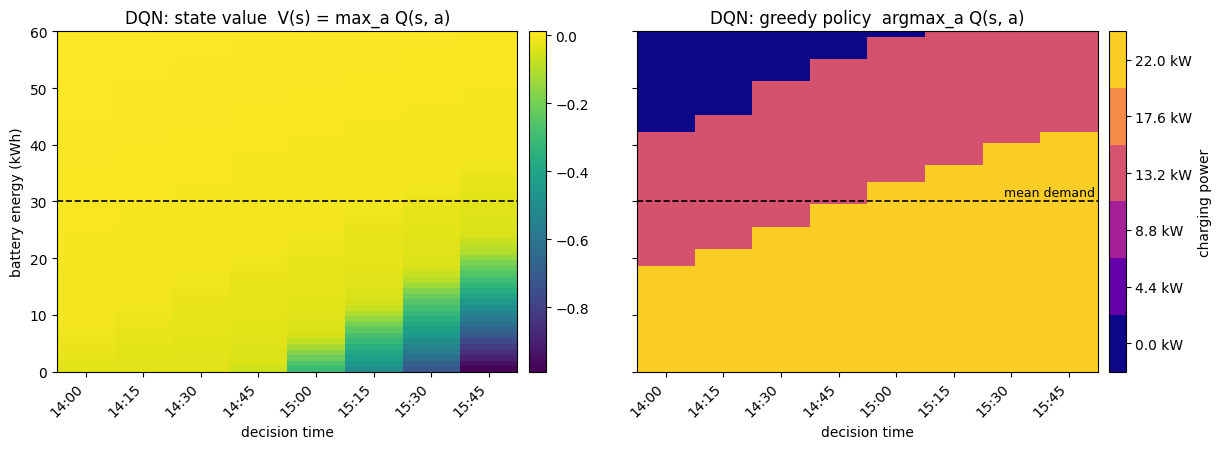

In [93]:
# the network answers any battery level, so evaluate it on a dense SoC grid
soc_fine = np.arange(0.0, BATTERY_CAPACITY + 0.01, 1.0)
obs_grid = np.array([[t / N_STEPS, e / BATTERY_CAPACITY]
                     for e in soc_fine for t in range(N_STEPS)], dtype=np.float32)
with torch.no_grad():
    q_grid = dqn_model.q_net(torch.as_tensor(obs_grid, device=dqn_model.device)).cpu().numpy()

V_dqn = q_grid.max(axis=1).reshape(len(soc_fine), N_STEPS)
P_dqn = q_grid.argmax(axis=1).reshape(len(soc_fine), N_STEPS).astype(float)

plot_value_and_policy(V_dqn, P_dqn, soc_fine, "DQN")

# Comparison
To compare the two approaches, Monte Carlo and DQN with the baseline, compare their learning curve using the average reward. The vlaues are based on 5000 episodes.

In [83]:
print(f"Monte Carlo training: {MC_FINAL_EPISODES} episodes")
summarize_results("Monte Carlo: greedy policy from the trained network", monte_carlo)

print("\n")

print(f"DQN training: {DQN_FINAL_TIMESTEPS} episodes")
summarize_results("DQN: greedy policy from the trained network", dqn)

print("\n")

print(f"Baseline: evenly spread charging to a full battery")
summarize_results("Baseline: evenly spread charging to a full battery", baseline)

Monte Carlo training: 250000 episodes
Monte Carlo: greedy policy from the trained network, 5000 episodes

mean charging cost      19.81
mean penalty             0.79
mean total reward      -20.60
episodes w/ shortfall   0.14%
mean shortfall          0.001 kWh
mean arrival SoC        20.01 kWh
mean final SoC          45.23 kWh


DQN training: 2000000 episodes
DQN: greedy policy from the trained network, 5000 episodes

mean charging cost      23.80
mean penalty             0.00
mean total reward      -23.80
episodes w/ shortfall   0.00%
mean shortfall          0.000 kWh
mean arrival SoC        20.01 kWh
mean final SoC          49.21 kWh


Baseline: evenly spread charging to a full battery
Baseline: evenly spread charging to a full battery, 5000 episodes

mean charging cost      41.77
mean penalty             0.00
mean total reward      -41.77
episodes w/ shortfall   0.00%
mean shortfall          0.000 kWh
mean arrival SoC        20.01 kWh
mean final SoC          59.42 kWh


## Comparison of learning curves
Belows diagram shows the learning curve. It shows how MC and DQN converge above the baseline.

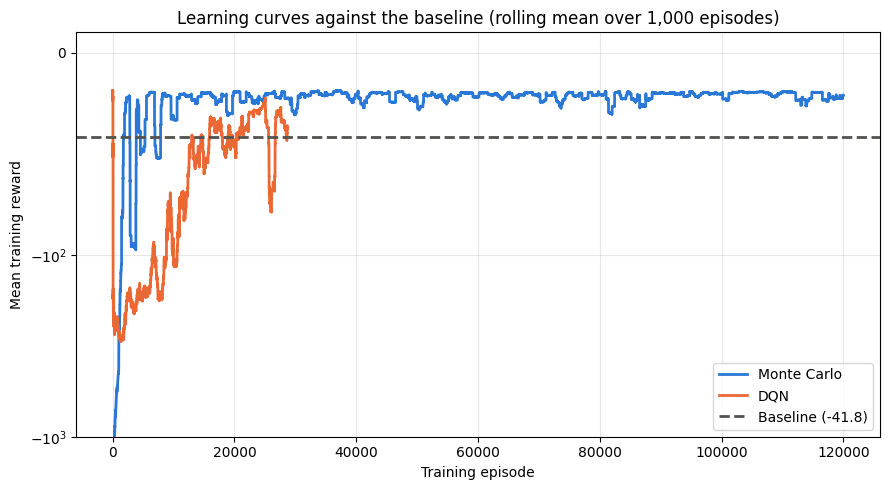

In [84]:
#| label: fig-learning-curves
#| fig-cap: "Learning curves of the Monte Carlo and DQN agents against the baseline, shown as a rolling mean over 1,000 episodes on a symmetric-log reward axis. The early episodes are dominated by the shortfall penalty."
MC_COLOR = "#2a78d6"
DQN_COLOR = "#eb6834"
BASELINE_COLOR = "#52514e"

SMOOTH_WINDOW = 1_000   # episodes per point of the learning curve

# one episode is always 8 steps for both agents, so the curves are comparable
baseline_reward = baseline["reward"].mean()
mc_curve = pd.Series(mc_episode_returns).rolling(SMOOTH_WINDOW, min_periods=1).mean()
dqn_curve = pd.Series(dqn_episode_returns).rolling(SMOOTH_WINDOW, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(mc_curve, color=MC_COLOR, lw=2, label="Monte Carlo")
ax.plot(dqn_curve, color=DQN_COLOR, lw=2, label="DQN")
ax.axhline(baseline_reward, color=BASELINE_COLOR, ls="--", lw=2,
           label=f"Baseline ({baseline_reward:.1f})")

# symlog: the first episodes are dominated by the 700 per kWh shortfall penalty
ax.set_yscale("symlog", linthresh=100)
ax.set_xlabel("Training episode")
ax.set_ylabel("Mean training reward")
ax.set_title(f"Learning curves against the baseline (rolling mean over {SMOOTH_WINDOW:,} episodes)")
# set y limit to 200
ax.set_ylim(-1000, 10)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

DQN starts with learning at 1000 timesteps, so 125 episodes. Previous guesses are just at random. Belows parameter is set to 125 episodes. We can see that both beath the baseline at around the same time.

In [85]:
# first episode at which the smoothed learning curve rises above the baseline
# (only counting episodes after the first 50)
MIN_EPISODE = 125

for name, curve in [("Monte Carlo", mc_curve), ("DQN", dqn_curve)]:
    curve_after = curve.iloc[MIN_EPISODE:]
    above = curve_after.ge(baseline_reward)
    beaten = f"after {int(above.idxmax()) + 1:,} episodes" if above.any() else "never"
    print(f"{name:<12} trained on {len(curve):>8,} episodes ({len(curve) * N_STEPS:>9,} steps) "
          f"| beats the baseline {beaten:<24} | final training reward {curve.iloc[-1]:8.2f}")

print(f"{'Baseline':<12} no training, mean reward {baseline_reward:.2f}")

Monte Carlo  trained on  120,000 episodes (  960,000 steps) | beats the baseline after 1,808 episodes     | final training reward   -21.14
DQN          trained on   28,750 episodes (  230,000 steps) | beats the baseline after 13,029 episodes    | final training reward   -37.43
Baseline     no training, mean reward -41.77


## Comparison of shortfall
The shortfall is the energy that is missing at departure. The demand is calculated at departure through a normal distribution and the penalty is 700 per missing kWh.
All three policies are evaluated on the same episodes, so the shares can be compared directly.
The baseline charges to a full battery every day and therefore never runs out, the two agents trade a small risk of a shortfall for a lower charging cost.

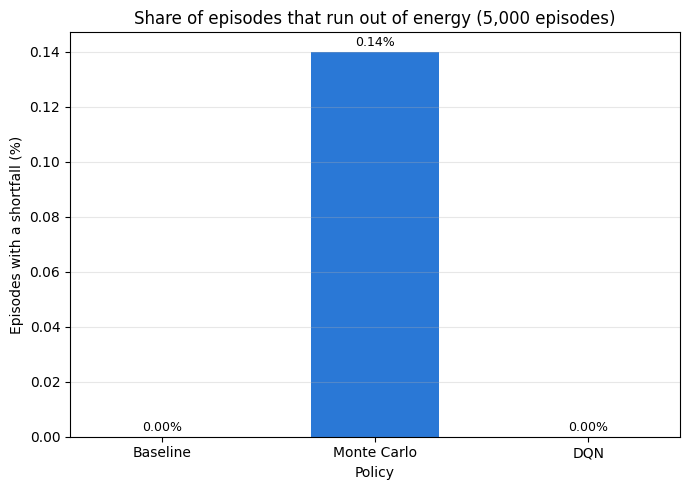

In [86]:
#| label: fig-shortfall-share
#| fig-cap: "Share of evaluation episodes in which each policy runs out of energy before departure, for the baseline, Monte Carlo, and DQN policies."
names = ["Baseline", "Monte Carlo", "DQN"]
colors = [BASELINE_COLOR, MC_COLOR, DQN_COLOR]
shortfall_share = [baseline["shortfall"].gt(0).mean() * 100,
                   monte_carlo["shortfall"].gt(0).mean() * 100,
                   dqn["shortfall"].gt(0).mean() * 100]

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(names, shortfall_share, color=colors, width=0.6)
for position, share in enumerate(shortfall_share):
    ax.annotate(f"{share:.2f}%", xy=(position, share), xytext=(0, 4),
                textcoords="offset points", ha="center", fontsize=9)

ax.set_xlabel("Policy")
ax.set_ylabel("Episodes with a shortfall (%)")
ax.set_title(f"Share of episodes that run out of energy ({len(baseline):,} episodes)")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## Distribution of arrival SoC
The arrival SoC has a different distribution as the demand SoC calculated at the end. Every policy is rolled out with the same seed per episode, so all three see exactly the same arrival states.
That is what makes the comparison fair, and it means one histogram describes the arrival SoC of all three policies.

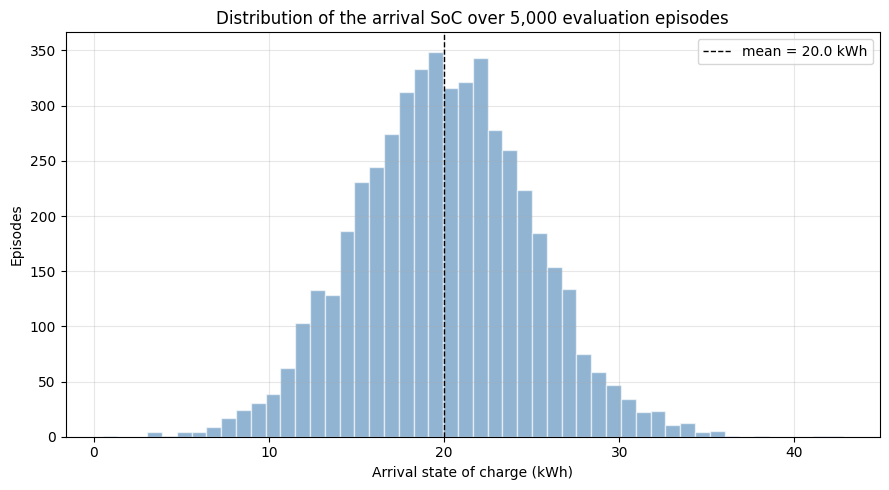

In [ ]:
#| label: fig-arrival-soc-distribution
#| fig-cap: "Distribution of the arrival state of charge over the evaluation episodes. The dashed line marks the mean arrival SoC."
arrival_soc = baseline["arrival_soc"]

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(arrival_soc, bins=50, color="steelblue", alpha=0.6, edgecolor="white")
ax.axvline(arrival_soc.mean(), color="black", ls="--", lw=1,
           label=f"mean = {arrival_soc.mean():.1f} kWh")

ax.set_xlabel("Arrival state of charge (kWh)")
ax.set_ylabel("Episodes")
ax.set_title(f"Distribution of the arrival SoC over {len(arrival_soc):,} evaluation episodes")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Distribution of power
Charging power decides the cost, because the cost grows exponentially with it.
Shown is the mean power an episode was charged with, so the three policies can be compared over the same 2 h session.
The baseline sits at the top of the action grid almost every day, while both agents settle around the power that just covers the expected demand.

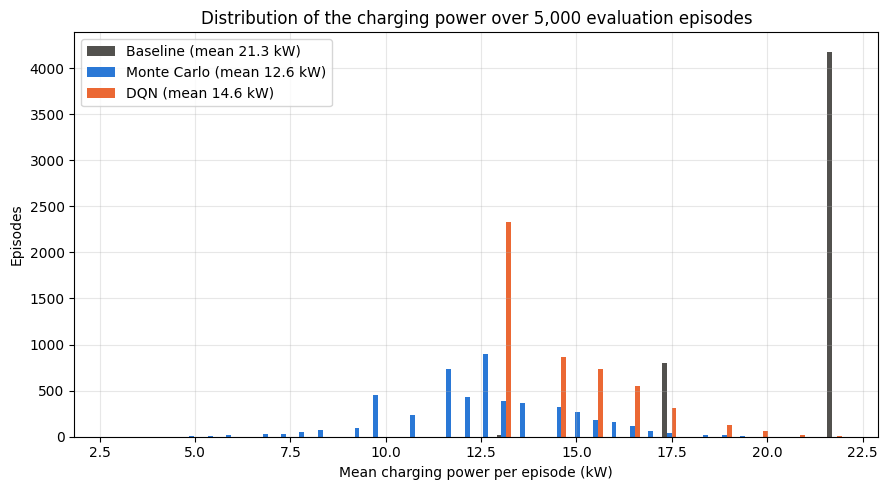

In [90]:
#| label: fig-charging-power-distribution
#| fig-cap: "Distribution of the mean charging power per episode for the baseline, Monte Carlo, and DQN policies over the evaluation episodes."
fig, ax = plt.subplots(figsize=(9, 5))

# Group the data, colors, and labels into lists
data = [baseline["power"], monte_carlo["power"], dqn["power"]]
colors = [BASELINE_COLOR, MC_COLOR, DQN_COLOR]
labels = [
    f"Baseline (mean {baseline['power'].mean():.1f} kW)",
    f"Monte Carlo (mean {monte_carlo['power'].mean():.1f} kW)",
    f"DQN (mean {dqn['power'].mean():.1f} kW)"
]

# Passing a list of arrays to ax.hist creates a grouped bar chart
ax.hist(data, bins=40, color=colors, label=labels)

ax.set_xlabel("Mean charging power per episode (kW)")
ax.set_ylabel("Episodes")
ax.set_title(f"Distribution of the charging power over {len(baseline):,} evaluation episodes")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Distribution of SoC states
The final SoC is the battery level at departure. The agents are trying to keep the SoC as low as possible while avoiding the penalty for missing energy.
The three policies see the same arrival states but decide differently, so unlike the arrival SoC each one has its own final distribution.
The baseline charges to a full battery, so its final SoC piles up near 60 kWh, while both agents stop lower, around the level that just covers the expected demand and leaves only a small shortfall risk.

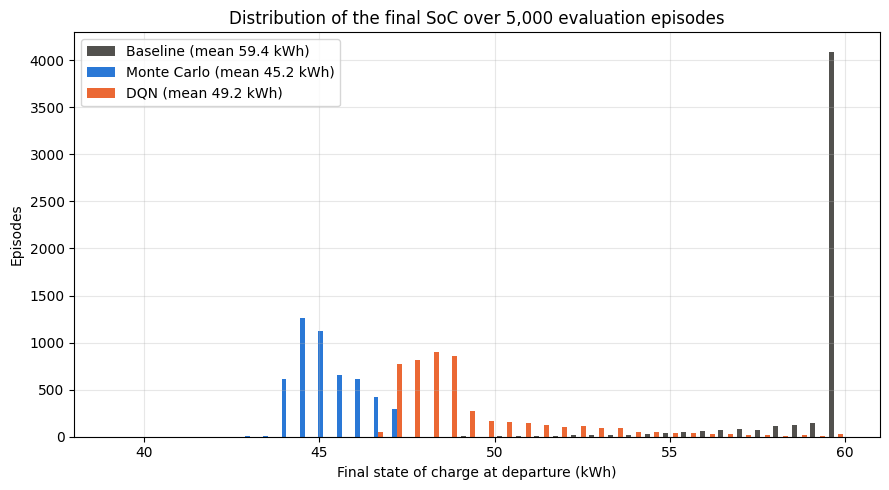

In [ ]:
#| label: fig-final-soc-distribution
#| fig-cap: "Distribution of the final state of charge at departure for the baseline, Monte Carlo, and DQN policies over the evaluation episodes."
fig, ax = plt.subplots(figsize=(9, 5))


data = [baseline["final_soc"], monte_carlo["final_soc"], dqn["final_soc"]]
colors = [BASELINE_COLOR, MC_COLOR, DQN_COLOR]
labels = [
    f"Baseline (mean {baseline['final_soc'].mean():.1f} kWh)",
    f"Monte Carlo (mean {monte_carlo['final_soc'].mean():.1f} kWh)",
    f"DQN (mean {dqn['final_soc'].mean():.1f} kWh)",
]


ax.hist(data, bins=40, color=colors, label=labels)

ax.set_xlabel("Final state of charge at departure (kWh)")
ax.set_ylabel("Episodes")
ax.set_title(f"Distribution of the final SoC over {len(baseline):,} evaluation episodes")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary

Three charging policies were compared on the **same** evaluation episodes, each trying
to have the car charged by departure at the lowest electricity cost:

- **Baseline**: a fixed rule that spreads the energy needed for a full battery
  evenly over the eight time slots. It never runs out of energy, but it nearly always charges with close to maximum power.
- **Monte Carlo control**: a tabular agent that learns a value for each (time, state-of-charge) cell from complete episodes and then charges greedily. It allows even lower final SoC states than DQN but has a very small risk of shortfall.
- **DQN**: a neural-network agent trained on the same amount of environment interaction, with an early-stopping schedule aligned to the Monte Carlo one.

The table below reports the mean per-episode outcome for each policy. Both learning
agents reach a **higher mean reward** (lower cost plus shortfall penalty) than the
baseline: they leave the battery a little below full and shift charging toward the
cheaper hours, accepting a small shortfall risk in exchange for a clearly lower
charging cost. The baseline is the only policy that never incurs a shortfall, which
is why it is also the most expensive.

In [ ]:
policies = {"Baseline": baseline, "Monte Carlo": monte_carlo, "DQN": dqn}

summary_table = pd.DataFrame({
    "mean cost":              {n: r["cost"].mean()                for n, r in policies.items()},
    "mean penalty":           {n: r["penalty"].mean()             for n, r in policies.items()},
    "mean reward":            {n: r["reward"].mean()              for n, r in policies.items()},
    "shortfall episodes (%)": {n: r["shortfall"].gt(0).mean() * 100 for n, r in policies.items()},
    "mean shortfall (kWh)":   {n: r["shortfall"].mean()           for n, r in policies.items()},
    "mean final SoC (kWh)":   {n: r["final_soc"].mean()           for n, r in policies.items()},
}).round(2)

best = summary_table["mean reward"].idxmax()
cost_saving = baseline["cost"].mean() - summary_table.loc[best, "mean cost"]

print(f"Evaluated on the same {len(baseline):,} episodes.")
print(f"Best mean reward: {best} ({summary_table.loc[best, 'mean reward']:.2f}), "
      f"charging cost {cost_saving:.2f} lower than the baseline "
      f"({cost_saving / baseline['cost'].mean():.0%}).")

summary_table

Evaluated on the same 5,000 episodes.
Best mean reward: Monte Carlo (-20.60), charging cost 21.96 lower than the baseline (53%).


,mean cost,mean penalty,mean reward,shortfall episodes (%),mean shortfall (kWh),mean final SoC (kWh)
Baseline,41.77,0.00,-41.77,0.00,0.0,59.42
Monte Carlo,19.81,0.79,-20.60,0.14,0.0,45.23
DQN,23.80,0.00,-23.80,0.00,0.0,49.21
